# TPMT/NUDT15 Pharmacogenomic MRD Classifier — TARGET-ALL-P2 & MAGIC-I

Pharmacogenomic classifiers for MRD status in paediatric ALL, built and validated across the TARGET-ALL-P2 (training/internal test) and MAGIC-I (external validation) cohorts.

**Note:** this notebook reads data from local paths under `/Users/Meralle/...` — update these paths if running on a different machine. Any table containing sample/patient identifiers is saved to CSV rather than displayed inline in this notebook.

## 1. Load TARGET-ALL-P2 merged clinical/pharmacogenomic data and raw gene counts

In [1]:
import pandas as pd

merged = pd.read_csv("/Users/Meralle/PyCharmMiscProject/TARGET_ALL_P2_merged_MRD.csv", index_col=0)
counts = pd.read_csv("/Users/Meralle/PyCharmMiscProject/TARGET_ALL_P2_counts_MRD_samples.csv", index_col=0)

print("merged shape:", merged.shape)
print("merged columns:", merged.columns.tolist())
print()
print("counts shape:", counts.shape)
print("counts index (genes):", counts.index[:5].tolist())

merged shape: (375, 11)
merged columns: ['TPMT', 'NUDT15', 'submitter_id', 'mrd_status', 'gender', 'race', 'age_at_diagnosis_years', 'subtype', 'vital_status', 'mrd_value_eoi', 'mrd_days_to_test']

counts shape: (60660, 375)
counts index (genes): ['TSPAN6', 'TNMD', 'DPM1', 'SCYL3', 'C1orf112']


## 2. DESeq2 normalisation and variance-stabilising transform (VST) of TARGET counts

In [2]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference

counts_dedup = counts.groupby(level=0).sum()
print("Before dedup:", counts.shape, "-> After dedup:", counts_dedup.shape)

counts_t = counts_dedup.T  # samples x genes
counts_t = counts_t.loc[merged.index]

nonzero_genes = counts_t.sum(axis=0) > 0
counts_t = counts_t.loc[:, nonzero_genes]
print("Counts after dropping all-zero genes:", counts_t.shape)

meta = merged[["mrd_status"]].copy()

inference = DefaultInference(n_cpus=4)
dds = DeseqDataSet(
    counts=counts_t,
    metadata=meta,
    design="~mrd_status",
    refit_cooks=True,
    inference=inference,
)
dds.deseq2()
dds.vst()

vst_df = pd.DataFrame(
    dds.layers["vst_counts"],
    index=counts_t.index,
    columns=counts_t.columns,
)
print("VST matrix shape:", vst_df.shape)
vst_df.to_csv("/Users/Meralle/PyCharmMiscProject/TARGET_ALL_P2_VST_full.csv")
print("Saved.")

Before dedup: (60660, 375) -> After dedup: (59427, 375)
Counts after dropping all-zero genes: (375, 57073)
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.33 seconds.

Fitting dispersions...
... done in 6.67 seconds.

Fitting dispersion trend curve...
... done in 0.34 seconds.

Fitting MAP dispersions...
... done in 7.14 seconds.

Fitting LFCs...
... done in 5.62 seconds.

Calculating cook's distance...
... done in 0.76 seconds.

Replacing 10263 outlier genes.

Fitting dispersions...
... done in 1.31 seconds.

Fitting MAP dispersions...
... done in 1.35 seconds.

Fitting LFCs...
... done in 1.16 seconds.

Fitting size factors...


Fit type used for VST : parametric
Using None as control genes, passed at DeseqDataSet initialization


... done in 0.31 seconds.

Fitting dispersions...
... done in 7.29 seconds.



VST matrix shape: (375, 57073)
Saved.


## 3. Define the thiopurine pathway gene set, the binary MRD outcome, and the stratified 80/20 train/test split

In [3]:
from sklearn.model_selection import train_test_split

thiopurine_genes = [
    "TPMT", "NUDT15", "ITPA", "HPRT1", "IMPDH1", "IMPDH2",
    "GMPS", "XDH", "AOX1", "ATIC", "RRM1", "RRM2",
    "ABCC4", "SLC28A2", "SLC28A3", "TYMS"
]

available = [g for g in thiopurine_genes if g in vst_df.columns]
missing = [g for g in thiopurine_genes if g not in vst_df.columns]
print("Available:", available)
print("Missing:", missing)

y = merged["mrd_status"].map({"MRD_neg": 0, "MRD_pos": 1})
print(y.value_counts())

train_idx, test_idx = train_test_split(
    merged.index, test_size=0.2, stratify=y, random_state=42
)
print("Train:", len(train_idx), "Test:", len(test_idx))
print("Train MRD balance:\n", y.loc[train_idx].value_counts(normalize=True))
print("Test MRD balance:\n", y.loc[test_idx].value_counts(normalize=True))

pd.Series(train_idx).to_csv("/Users/Meralle/PyCharmMiscProject/TARGET_train_ids.csv", index=False)
pd.Series(test_idx).to_csv("/Users/Meralle/PyCharmMiscProject/TARGET_test_ids.csv", index=False)

Available: ['TPMT', 'NUDT15', 'ITPA', 'HPRT1', 'IMPDH1', 'IMPDH2', 'GMPS', 'XDH', 'AOX1', 'ATIC', 'RRM1', 'RRM2', 'ABCC4', 'SLC28A2', 'SLC28A3', 'TYMS']
Missing: []
mrd_status
0    243
1    132
Name: count, dtype: int64
Train: 300 Test: 75
Train MRD balance:
 mrd_status
0    0.646667
1    0.353333
Name: proportion, dtype: float64
Test MRD balance:
 mrd_status
0    0.653333
1    0.346667
Name: proportion, dtype: float64


## 4. Model A — logistic regression on TPMT + NUDT15

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, classification_report

features_A = ["TPMT", "NUDT15"]

X_train_A = vst_df.loc[train_idx, features_A]
X_test_A = vst_df.loc[test_idx, features_A]
y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

scaler_A = StandardScaler()
X_train_A_scaled = scaler_A.fit_transform(X_train_A)
X_test_A_scaled = scaler_A.transform(X_test_A)

model_A = LogisticRegression(class_weight="balanced", random_state=42)
model_A.fit(X_train_A_scaled, y_train)

pred_proba_A = model_A.predict_proba(X_test_A_scaled)[:, 1]
pred_A = model_A.predict(X_test_A_scaled)

print("=== Model A: TPMT + NUDT15 ===")
print("ROC-AUC:", roc_auc_score(y_test, pred_proba_A))
print("PR-AUC:", average_precision_score(y_test, pred_proba_A))
print("F1:", f1_score(y_test, pred_A))
print(classification_report(y_test, pred_A))
print("Coefficients:", dict(zip(features_A, model_A.coef_[0])))

=== Model A: TPMT + NUDT15 ===
ROC-AUC: 0.6232339089481946
PR-AUC: 0.4849598338001486
F1: 0.53125
              precision    recall  f1-score   support

           0       0.76      0.57      0.65        49
           1       0.45      0.65      0.53        26

    accuracy                           0.60        75
   macro avg       0.60      0.61      0.59        75
weighted avg       0.65      0.60      0.61        75

Coefficients: {'TPMT': np.float64(0.608085210735711), 'NUDT15': np.float64(-0.1490884387327379)}


## 5. Load ALLSorts B-ALL subtype calls

In [5]:
import pickle

with open("/Users/Meralle/PyCharmMiscProject/data/allsorts_results.pkl", "rb") as f:
    allsorts_results = pickle.load(f)

print(type(allsorts_results))
if hasattr(allsorts_results, "shape"):
    print(allsorts_results.shape)
    print(allsorts_results.columns.tolist() if hasattr(allsorts_results, "columns") else "no columns attr")
    print(allsorts_results.head())
else:
    print(allsorts_results)

<class 'pandas.DataFrame'>
(433, 2)
['Prediction', 'subtype_primary']
                       Prediction subtype_primary
TARGET-10-PATNIA     Unclassified    Unclassified
TARGET-10-PARVEI     Unclassified    Unclassified
TARGET-10-PARWLP     Unclassified    Unclassified
TARGET-10-PATEYS     Unclassified    Unclassified
TARGET-10-PAPPGN  PAX5alt,Ph-like         PAX5alt


In [6]:
print(allsorts_results["subtype_primary"].value_counts())

subtype_primary
Unclassified         221
Ph-like               46
High hyperdiploid     31
PAX5alt               30
KMT2A Group           19
TCF3-PBX1             17
ETV6-RUNX1            14
ZNF384 Group          12
High Sig               9
MEF2D                  5
Ph                     5
iAMP21                 4
HLF                    4
Ph Group               3
Low hyperdiploid       3
ETV6-RUNX1-like        3
NUTM1                  2
DUX4                   2
PAX5 P80R              2
ETV6-RUNX1 Group       1
Name: count, dtype: int64


Treated 221 Unclassified samples as its own category for the subtype-adjusted Model A (TPMT + NUDT15 + subtype)

## 6. Model A + ALLSorts subtype covariate

In [7]:
subtype_col = allsorts_results.loc[merged.index, "subtype_primary"]
subtype_dummies = pd.get_dummies(subtype_col, prefix="subtype", drop_first=True)
print(subtype_dummies.shape)

X_train_B = pd.concat([X_train_A, subtype_dummies.loc[train_idx]], axis=1)
X_test_B = pd.concat([X_test_A, subtype_dummies.loc[test_idx]], axis=1)

X_train_B, X_test_B = X_train_B.align(X_test_B, join="left", axis=1, fill_value=0)

cont_cols = features_A
scaler_B = StandardScaler()
X_train_B_scaled = X_train_B.copy()
X_test_B_scaled = X_test_B.copy()
X_train_B_scaled[cont_cols] = scaler_B.fit_transform(X_train_B[cont_cols])
X_test_B_scaled[cont_cols] = scaler_B.transform(X_test_B[cont_cols])

model_A_subtype = LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000)
model_A_subtype.fit(X_train_B_scaled, y_train)

pred_proba_A_sub = model_A_subtype.predict_proba(X_test_B_scaled)[:, 1]
pred_A_sub = model_A_subtype.predict(X_test_B_scaled)

print("=== Model A + ALLSorts subtype: TPMT + NUDT15 + subtype ===")
print("ROC-AUC:", roc_auc_score(y_test, pred_proba_A_sub))
print("PR-AUC:", average_precision_score(y_test, pred_proba_A_sub))
print("F1:", f1_score(y_test, pred_A_sub))
print(classification_report(y_test, pred_A_sub))

(375, 19)
=== Model A + ALLSorts subtype: TPMT + NUDT15 + subtype ===
ROC-AUC: 0.6240188383045526
PR-AUC: 0.5015462816297572
F1: 0.5161290322580645
              precision    recall  f1-score   support

           0       0.74      0.59      0.66        49
           1       0.44      0.62      0.52        26

    accuracy                           0.60        75
   macro avg       0.59      0.60      0.59        75
weighted avg       0.64      0.60      0.61        75



## 7. Model B — full 16-gene thiopurine pathway panel

In [8]:
features_B = available  # all 16 pathway genes

X_train_C = vst_df.loc[train_idx, features_B]
X_test_C = vst_df.loc[test_idx, features_B]

scaler_C = StandardScaler()
X_train_C_scaled = scaler_C.fit_transform(X_train_C)
X_test_C_scaled = scaler_C.transform(X_test_C)

model_B = LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000)
model_B.fit(X_train_C_scaled, y_train)

pred_proba_B = model_B.predict_proba(X_test_C_scaled)[:, 1]
pred_B = model_B.predict(X_test_C_scaled)

print("=== Model B: Full thiopurine pathway (16 genes) ===")
print("ROC-AUC:", roc_auc_score(y_test, pred_proba_B))
print("PR-AUC:", average_precision_score(y_test, pred_proba_B))
print("F1:", f1_score(y_test, pred_B))
print(classification_report(y_test, pred_B))
print("Coefficients:")
for gene, coef in sorted(zip(features_B, model_B.coef_[0]), key=lambda x: -abs(x[1])):
    print(f"  {gene}: {coef:.4f}")

=== Model B: Full thiopurine pathway (16 genes) ===
ROC-AUC: 0.5934065934065933
PR-AUC: 0.418796532523531
F1: 0.39285714285714285
              precision    recall  f1-score   support

           0       0.67      0.61      0.64        49
           1       0.37      0.42      0.39        26

    accuracy                           0.55        75
   macro avg       0.52      0.52      0.52        75
weighted avg       0.56      0.55      0.55        75

Coefficients:
  GMPS: 0.7532
  TPMT: 0.6968
  HPRT1: -0.5927
  RRM2: -0.5583
  ITPA: 0.3334
  IMPDH2: 0.3319
  AOX1: -0.3292
  XDH: 0.3246
  IMPDH1: 0.3083
  RRM1: -0.2140
  NUDT15: -0.2013
  SLC28A3: -0.1999
  SLC28A2: 0.1748
  ABCC4: -0.1661
  ATIC: -0.0743
  TYMS: 0.0249


## 8. Model C — genome-wide elastic-net logistic regression (all genes, TARGET internal test set)

In [9]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier
import numpy as np

X_train_full = vst_df.loc[train_idx]
X_test_full = vst_df.loc[test_idx]

scaler_full = StandardScaler()
X_train_full_scaled = scaler_full.fit_transform(X_train_full)
X_test_full_scaled = scaler_full.transform(X_test_full)

model_C_en = LogisticRegressionCV(
    penalty="elasticnet",
    solver="saga",
    l1_ratios=[0.1, 0.5, 0.9],
    Cs=5,
    cv=5,
    class_weight="balanced",
    max_iter=2000,
    n_jobs=-1,
    random_state=42,
)
model_C_en.fit(X_train_full_scaled, y_train)

pred_proba_C_en = model_C_en.predict_proba(X_test_full_scaled)[:, 1]
pred_C_en = model_C_en.predict(X_test_full_scaled)

print("=== Model C: Elastic Net, all genes ===")
print("Best C:", model_C_en.C_, "Best l1_ratio:", model_C_en.l1_ratio_)
print("ROC-AUC:", roc_auc_score(y_test, pred_proba_C_en))
print("PR-AUC:", average_precision_score(y_test, pred_proba_C_en))
print("F1:", f1_score(y_test, pred_C_en))
print(classification_report(y_test, pred_C_en))

n_nonzero = np.sum(model_C_en.coef_[0] != 0)
print(f"Non-zero coefficients: {n_nonzero} / {X_train_full.shape[1]}")

/Users/Meralle/PyCharmMiscProject/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/Meralle/PyCharmMiscProject/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/Meralle/PyCharmMiscProject/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/Meralle/PyCharmMiscProject/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/Meralle/PyCharmMiscProject/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not conver

=== Model C: Elastic Net, all genes ===
Best C: [0.01] Best l1_ratio: [0.1]
ROC-AUC: 0.7409733124018839
PR-AUC: 0.5893712972741252
F1: 0.6382978723404256
              precision    recall  f1-score   support

           0       0.80      0.88      0.83        49
           1       0.71      0.58      0.64        26

    accuracy                           0.77        75
   macro avg       0.76      0.73      0.74        75
weighted avg       0.77      0.77      0.77        75

Non-zero coefficients: 656 / 57073


## 9. Model C alternative — genome-wide random forest

In [10]:
model_C_rf = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    max_depth=None,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42,
)
model_C_rf.fit(X_train_full_scaled, y_train)

pred_proba_C_rf = model_C_rf.predict_proba(X_test_full_scaled)[:, 1]
pred_C_rf = model_C_rf.predict(X_test_full_scaled)

print("=== Model C: Random Forest, all genes ===")
print("ROC-AUC:", roc_auc_score(y_test, pred_proba_C_rf))
print("PR-AUC:", average_precision_score(y_test, pred_proba_C_rf))
print("F1:", f1_score(y_test, pred_C_rf))
print(classification_report(y_test, pred_C_rf))

importances = pd.Series(model_C_rf.feature_importances_, index=X_train_full.columns)
print("\nTop 20 genes by importance:")
print(importances.sort_values(ascending=False).head(20))

=== Model C: Random Forest, all genes ===
ROC-AUC: 0.7229199372056515
PR-AUC: 0.5706293015642828
F1: 0.41025641025641024
              precision    recall  f1-score   support

           0       0.71      0.90      0.79        49
           1       0.62      0.31      0.41        26

    accuracy                           0.69        75
   macro avg       0.66      0.60      0.60        75
weighted avg       0.68      0.69      0.66        75


Top 20 genes by importance:
gene_name
STBD1         0.002740
ABCA2         0.001876
AC106865.2    0.001815
E2F2          0.001745
DGKH          0.001494
AKTIP         0.001483
SERPINB1      0.001482
C3orf52       0.001367
LINC00674     0.001342
STARD3NL      0.001330
AL035587.1    0.001330
BMP1          0.001273
TBILA         0.001271
GOLGA8N       0.001247
ANTXR2        0.001230
TMPRSS7       0.001228
SPNS3         0.001216
GOLGA8Q       0.001213
MAPK6P3       0.001206
FSTL3         0.001147
dtype: float64


## 10. Collect elastic-net test-set probabilities for the ROC-AUC comparison below (this value is later overwritten once Model C is refit on the TARGET∩MAGIC-I common gene space)

In [11]:
pred_proba_common = model_C_en.predict_proba(X_test_full_scaled)[:, 1]

## 11. Compare test-set ROC-AUC across Models A, A+subtype, B, and C (TARGET internal test set)

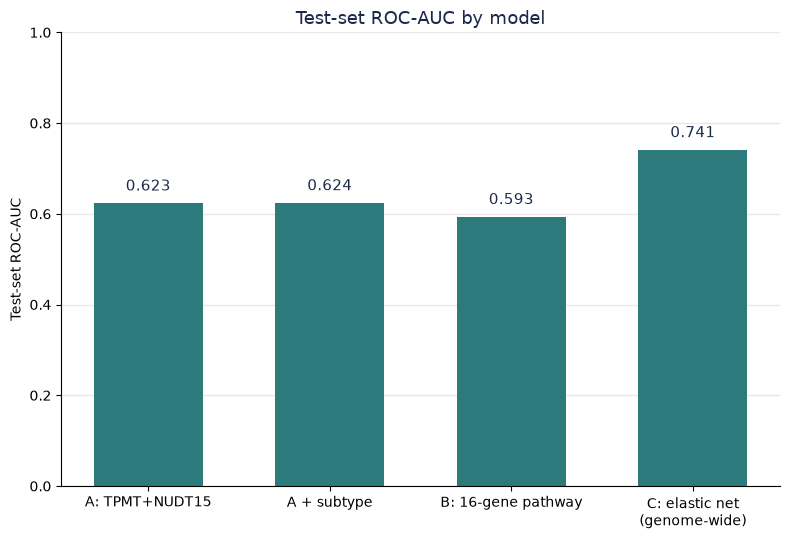

In [12]:
import matplotlib.pyplot as plt

models = ["A: TPMT+NUDT15", "A + subtype", "B: 16-gene pathway", "C: elastic net\n(genome-wide)"]
roc_auc = [
    roc_auc_score(y_test, pred_proba_A),
    roc_auc_score(y_test, pred_proba_A_sub),
    roc_auc_score(y_test, pred_proba_B),
    roc_auc_score(y_test, pred_proba_common),
]

fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.bar(models, roc_auc, color="#2C7A7B", width=0.6)

for bar, val in zip(bars, roc_auc):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"{val:.3f}", ha="center", va="bottom", fontsize=11, color="#1B2A4A")

ax.set_ylim(0, 1)
ax.set_ylabel("Test-set ROC-AUC")
ax.set_title("Test-set ROC-AUC by model", fontsize=13, color="#1B2A4A")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#E8E8E8", linewidth=1, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("classifier_roc_auc_comparison.png", dpi=300)
plt.show()

## 12. Load the MAGIC-I external validation cohort — RNA-seq counts and sample manifest

In [13]:
magic_counts = pd.read_csv("~/Desktop/research data/magic-i-expression-data/cohort-counts.tsv", sep="\t", index_col=0)
magic_manifest = pd.read_csv("~/Desktop/research data/magic-i-expression-data/cohort-counts-manifest.csv")

print("MAGIC-I counts shape:", magic_counts.shape)
print()
print("Manifest columns:", magic_manifest.columns.tolist())
print("Manifest samples:", len(magic_manifest))

MAGIC-I counts shape: (62700, 70)

Manifest columns: ['sample', 'study_id', 'disease', 'rin']
Manifest samples: 70


## 13. Transpose MAGIC-I counts to samples × genes

In [14]:
magic_counts_t = magic_counts.T

## 14. DESeq2/VST normalisation of the MAGIC-I cohort

In [15]:
magic_counts_t_clean = magic_counts_t.drop(index=['A3870478', 'A3872460', 'A3873043', 'A3873076'])
print("Shape after dropping NaN samples:", magic_counts_t_clean.shape)
print("Remaining NaNs:", magic_counts_t_clean.isna().sum().sum())

nonzero = magic_counts_t_clean.sum(axis=0) > 0
magic_counts_t_clean = magic_counts_t_clean.loc[:, nonzero]
print("Shape after dropping zero genes:", magic_counts_t_clean.shape)

meta_magic = pd.DataFrame(index=magic_counts_t_clean.index)
meta_magic["dummy"] = "1"

inference_magic = DefaultInference(n_cpus=4)
dds_magic = DeseqDataSet(
    counts=magic_counts_t_clean,
    metadata=meta_magic,
    design="~1",
    inference=inference_magic,
)
dds_magic.deseq2()
dds_magic.vst()

vst_magic = pd.DataFrame(
    dds_magic.layers["vst_counts"],
    index=magic_counts_t_clean.index,
    columns=magic_counts_t_clean.columns,
)
print("MAGIC-I VST shape:", vst_magic.shape)
vst_magic.to_csv("/Users/Meralle/PyCharmMiscProject/MAGIC_I_VST_full.csv")
print("Saved.")

Shape after dropping NaN samples: (66, 62700)
Remaining NaNs: 0
Shape after dropping zero genes: (66, 54563)
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.05 seconds.

Fitting dispersions...
... done in 5.03 seconds.

Fitting dispersion trend curve...
... done in 0.44 seconds.

Fitting MAP dispersions...
... done in 6.16 seconds.

Fitting LFCs...
... done in 4.32 seconds.

Calculating cook's distance...
... done in 0.11 seconds.

Replacing 9378 outlier genes.

Fitting dispersions...
... done in 0.94 seconds.

Fitting MAP dispersions...
... done in 0.94 seconds.

Fitting LFCs...
... done in 0.87 seconds.

Fitting size factors...
... done in 0.05 seconds.



Fit type used for VST : parametric
Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 5.13 seconds.



MAGIC-I VST shape: (66, 54563)
Saved.


## 15. Map MAGIC-I Ensembl gene IDs to gene symbols

In [16]:
import subprocess
subprocess.run(["pip", "install", "mygene", "--quiet"])

import mygene
mg = mygene.MyGeneInfo()

ensembl_ids = [g.split(".")[0] for g in vst_magic.columns]

query_result = mg.querymany(ensembl_ids, scopes="ensembl.gene", fields="symbol", species="human")
id_to_symbol = {r["query"]: r.get("symbol") for r in query_result if "symbol" in r}

print(f"Mapped {len(id_to_symbol)} / {len(ensembl_ids)} genes")

31 input query terms found dup hits:	[('ENSG00000117262', 2), ('ENSG00000188092', 2), ('ENSG00000188660', 2), ('ENSG00000215156', 2), ('E
1205 input query terms found no hit:	['ENSG00000002079', 'ENSG00000131484', 'ENSG00000132832', 'ENSG00000139656', 'ENSG00000146521', 'ENS


Mapped 39720 / 54563 genes


In [17]:
vst_magic_symbols = vst_magic.rename(columns=id_to_symbol)
vst_magic_symbols = vst_magic_symbols.loc[:, vst_magic_symbols.columns.notna()]

vst_magic_symbols = vst_magic_symbols.T.groupby(level=0).mean().T
print("MAGIC-I symbol-mapped shape:", vst_magic_symbols.shape)

model_A_genes = features_A
model_B_genes = features_B
model_C_genes = X_train_full.columns  # all genes used in elastic net / RF training

missing_A = [g for g in model_A_genes if g not in vst_magic_symbols.columns]
missing_B = [g for g in model_B_genes if g not in vst_magic_symbols.columns]
overlap_C = [g for g in model_C_genes if g in vst_magic_symbols.columns]

print("Model A missing genes:", missing_A)
print("Model B missing genes:", missing_B)
print(f"Model C gene overlap: {len(overlap_C)} / {len(model_C_genes)}")

MAGIC-I symbol-mapped shape: (66, 53847)
Model A missing genes: []
Model B missing genes: []
Model C gene overlap: 32651 / 57073


Model A/B fully covered. Need to check whether 762 non-zero elastic genes are covered for Model C.

In [18]:
en_coefs = pd.Series(model_C_en.coef_[0], index=X_train_full.columns)
selected_genes = en_coefs[en_coefs != 0].index.tolist()
missing_selected = [g for g in selected_genes if g not in vst_magic_symbols.columns]

print(f"Elastic net selected genes: {len(selected_genes)}")
print(f"Missing from MAGIC-I: {len(missing_selected)}")
print(f"Coverage: {(len(selected_genes)-len(missing_selected))/len(selected_genes)*100:.1f}%")

Elastic net selected genes: 656
Missing from MAGIC-I: 252
Coverage: 61.6%


Refit using Ensemble IDs directly

## 16. Preview a raw TARGET STAR gene-count file to confirm the Ensembl ID format

In [19]:
sample_file = "/Users/Meralle/PyCharmMiscProject/target_all_extracted/efd90c6d-d9c9-4994-8a88-409d51bc1c07/f91c0d2e-6023-4e2c-b285-0b75d1493bcf.rna_seq.augmented_star_gene_counts.tsv"
preview = pd.read_csv(sample_file, sep="\t", skiprows=1)
print(preview.columns.tolist())
print(preview.head(10))

['gene_id', 'gene_name', 'gene_type', 'unstranded', 'stranded_first', 'stranded_second', 'tpm_unstranded', 'fpkm_unstranded', 'fpkm_uq_unstranded']
              gene_id gene_name       gene_type  unstranded  stranded_first  \
0          N_unmapped       NaN             NaN     2526219         2526219   
1      N_multimapping       NaN             NaN    11412887        11412887   
2         N_noFeature       NaN             NaN     6640804        40495157   
3         N_ambiguous       NaN             NaN    11781677           55192   
4  ENSG00000000003.15    TSPAN6  protein_coding           1               0   
5   ENSG00000000005.6      TNMD  protein_coding           0               0   
6  ENSG00000000419.13      DPM1  protein_coding         916               1   
7  ENSG00000000457.14     SCYL3  protein_coding         248             157   
8  ENSG00000000460.17  C1orf112  protein_coding         804              80   
9  ENSG00000000938.13       FGR  protein_coding         261   

## 17. Map TARGET gene symbols to Ensembl IDs (reverse mapping)

In [20]:
target_symbols = vst_df.columns.tolist()
query_result_2 = mg.querymany(target_symbols, scopes="symbol", fields="ensembl.gene", species="human")

symbol_to_ensembl = {}
for r in query_result_2:
    ens = r.get("ensembl")
    if ens:
        if isinstance(ens, list):
            ens_id = ens[0]["gene"]
        else:
            ens_id = ens["gene"]
        symbol_to_ensembl[r["query"]] = ens_id

print(f"Mapped {len(symbol_to_ensembl)} / {len(target_symbols)} TARGET genes to Ensembl")

6637 input query terms found dup hits:	[('5S_rRNA', 10), ('7SK', 10), ('A2ML1-AS1', 2), ('A2ML1-AS2', 2), ('AACSP1', 2), ('AADACL2-AS1', 3)
19876 input query terms found no hit:	['5_8S_rRNA', 'AATK', 'ABALON', 'ABBA01000933.1', 'ABBA01000935.2', 'ABBA01006766.1', 'ABBA01045074.


Mapped 36964 / 57073 TARGET genes to Ensembl


In [21]:
vst_magic.columns = [c.split(".")[0] for c in vst_magic.columns]
vst_magic_dedup = vst_magic.T.groupby(level=0).mean().T  # in case of dup after stripping version

vst_df_ensembl = vst_df.rename(columns=symbol_to_ensembl)
vst_df_ensembl = vst_df_ensembl.loc[:, vst_df_ensembl.columns.isin(symbol_to_ensembl.values())]
vst_df_ensembl = vst_df_ensembl.T.groupby(level=0).mean().T  # dedupe symbols mapping to same Ensembl ID
print("TARGET Ensembl-indexed shape:", vst_df_ensembl.shape)

selected_ensembl = [symbol_to_ensembl[g] for g in selected_genes if g in symbol_to_ensembl]
missing_selected_ens = [g for g in selected_ensembl if g not in vst_magic_dedup.columns]

print(f"Selected genes mappable to Ensembl: {len(selected_ensembl)} / {len(selected_genes)}")
print(f"Of those, missing from MAGIC-I: {len(missing_selected_ens)}")
print(f"Coverage: {(len(selected_ensembl)-len(missing_selected_ens))/len(selected_ensembl)*100:.1f}%")

TARGET Ensembl-indexed shape: (375, 36962)
Selected genes mappable to Ensembl: 455 / 656
Of those, missing from MAGIC-I: 75
Coverage: 83.5%


## 18. Refit Model C (elastic net) on the TARGET ∩ MAGIC-I common gene space

In [22]:
common_genes = [g for g in vst_df_ensembl.columns if g in vst_magic_dedup.columns]
print(f"Common genes available for Model C: {len(common_genes)}")

X_train_full_common = vst_df_ensembl.loc[train_idx, common_genes]
X_test_full_common = vst_df_ensembl.loc[test_idx, common_genes]

scaler_common = StandardScaler()
X_train_common_scaled = scaler_common.fit_transform(X_train_full_common)
X_test_common_scaled = scaler_common.transform(X_test_full_common)

model_C_en_common = LogisticRegressionCV(
    penalty="elasticnet",
    solver="saga",
    l1_ratios=[0.1, 0.5, 0.9],
    Cs=5,
    cv=5,
    class_weight="balanced",
    max_iter=2000,
    n_jobs=-1,
    random_state=42,
)
model_C_en_common.fit(X_train_common_scaled, y_train)

pred_proba_common = model_C_en_common.predict_proba(X_test_common_scaled)[:, 1]
pred_common = model_C_en_common.predict(X_test_common_scaled)

print("=== Model C (refit on TARGET∩MAGIC-I common genes) ===")
print("Best C:", model_C_en_common.C_, "Best l1_ratio:", model_C_en_common.l1_ratio_)
print("ROC-AUC:", roc_auc_score(y_test, pred_proba_common))
print("PR-AUC:", average_precision_score(y_test, pred_proba_common))
print("F1:", f1_score(y_test, pred_common))
n_nonzero_common = np.sum(model_C_en_common.coef_[0] != 0)
print(f"Non-zero coefficients: {n_nonzero_common} / {len(common_genes)}")

Common genes available for Model C: 31188


/Users/Meralle/PyCharmMiscProject/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/Meralle/PyCharmMiscProject/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/Meralle/PyCharmMiscProject/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/Meralle/PyCharmMiscProject/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/Meralle/PyCharmMiscProject/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not conver

=== Model C (refit on TARGET∩MAGIC-I common genes) ===
Best C: [0.01] Best l1_ratio: [0.1]
ROC-AUC: 0.7441130298273156
PR-AUC: 0.5885260925930661
F1: 0.6086956521739131
Non-zero coefficients: 443 / 31188


## 19. Map Model A and Model B gene symbols to Ensembl IDs for application to MAGIC-I

In [23]:
model_A_ensembl = [symbol_to_ensembl.get(g) for g in features_A]
model_B_ensembl = [symbol_to_ensembl.get(g) for g in features_B]
print("Model A Ensembl mapping:", dict(zip(features_A, model_A_ensembl)))
print("Model B Ensembl mapping:", dict(zip(features_B, model_B_ensembl)))
print("Any missing?", any(g is None for g in model_A_ensembl), any(g is None for g in model_B_ensembl))
print("All in MAGIC-I columns?",
      all(g in vst_magic_dedup.columns for g in model_A_ensembl if g),
      all(g in vst_magic_dedup.columns for g in model_B_ensembl if g))

Model A Ensembl mapping: {'TPMT': 'ENSG00000137364', 'NUDT15': 'ENSG00000136159'}
Model B Ensembl mapping: {'TPMT': 'ENSG00000137364', 'NUDT15': 'ENSG00000136159', 'ITPA': 'ENSG00000125877', 'HPRT1': 'ENSG00000165704', 'IMPDH1': 'ENSG00000106348', 'IMPDH2': 'ENSG00000178035', 'GMPS': 'ENSG00000163655', 'XDH': 'ENSG00000158125', 'AOX1': 'ENSG00000138356', 'ATIC': 'ENSG00000138363', 'RRM1': 'ENSG00000167325', 'RRM2': 'ENSG00000171848', 'ABCC4': 'ENSG00000125257', 'SLC28A2': 'ENSG00000137860', 'SLC28A3': 'ENSG00000197506', 'TYMS': 'ENSG00000176890'}
Any missing? False False
All in MAGIC-I columns? True True


## 20. Apply Models A, B, and C to the MAGIC-I cohort and save per-sample predictions

In [24]:
X_magic_A = vst_magic_dedup[model_A_ensembl].copy()
X_magic_A.columns = features_A  # rename Ensembl -> symbol to match scaler_A's fit columns
X_magic_A_scaled = scaler_A.transform(X_magic_A)
proba_A = model_A.predict_proba(X_magic_A_scaled)[:, 1]
pred_A_magic = model_A.predict(X_magic_A_scaled)

X_magic_B = vst_magic_dedup[model_B_ensembl].copy()
X_magic_B.columns = features_B
X_magic_B_scaled = scaler_C.transform(X_magic_B)
proba_B = model_B.predict_proba(X_magic_B_scaled)[:, 1]
pred_B_magic = model_B.predict(X_magic_B_scaled)

X_magic_C = vst_magic_dedup[common_genes]
X_magic_C_scaled = scaler_common.transform(X_magic_C)
proba_C = model_C_en_common.predict_proba(X_magic_C_scaled)[:, 1]
pred_C_magic = model_C_en_common.predict(X_magic_C_scaled)

results = pd.DataFrame({
    "sample_id": vst_magic_dedup.index,
    "modelA_TPMT_NUDT15_proba_MRDpos": proba_A,
    "modelA_TPMT_NUDT15_pred": np.where(pred_A_magic == 1, "MRD_pos", "MRD_neg"),
    "modelB_pathway16_proba_MRDpos": proba_B,
    "modelB_pathway16_pred": np.where(pred_B_magic == 1, "MRD_pos", "MRD_neg"),
    "modelC_elasticnet_allgenes_proba_MRDpos": proba_C,
    "modelC_elasticnet_allgenes_pred": np.where(pred_C_magic == 1, "MRD_pos", "MRD_neg"),
})

results = results.merge(magic_manifest[["sample", "disease"]], left_on="sample_id", right_on="sample", how="left")
results = results.drop(columns="sample")

print(results.shape)

results.to_csv("/Users/Meralle/PyCharmMiscProject/MAGIC_I_MRD_predictions.csv", index=False)
print("Saved to MAGIC_I_MRD_predictions.csv")

(66, 8)
Saved to MAGIC_I_MRD_predictions.csv


**Unresolved dependency:** `leukaemia_manifest_narrow` is used below but is never built earlier in this notebook — the upstream cell that derives it (likely `magic_manifest` filtered/cleaned down to the leukaemia-only "narrow" cohort) appears to be missing. As written, this cell will raise a `NameError`. Please restore or rebuild that upstream cell before running start to finish.

## 21. Restrict the MAGIC-I narrow leukaemia manifest and derive the B-ALL subset

In [27]:
leukaemia_manifest_narrow = leukaemia_manifest_narrow[
    leukaemia_manifest_narrow['sample'] != 'A3873043'
].copy()

print("MAGIC-I narrow cohort, n =", len(leukaemia_manifest_narrow))

MAGIC-I narrow cohort, n = 69


In [ ]:
def broad_lineage(d):
    d = d.upper()
    if 'MPAL' in d: return 'MPAL'
    if 'AML' in d: return 'AML'
    if 'T-ALL' in d or 'T-LBL' in d: return 'T-ALL'
    if 'B-ALL' in d or 'B, ALL' in d or 'DS-B-ALL' in d or 'B-LBL' in d: return 'B-ALL'
    return 'Other'

leukaemia_manifest_narrow['lineage'] = leukaemia_manifest_narrow['disease'].apply(broad_lineage)

ball_manifest = leukaemia_manifest_narrow[leukaemia_manifest_narrow['lineage'] == 'B-ALL']
print("B-ALL only:", len(ball_manifest))
print(ball_manifest['disease'].value_counts())

results_ball = results[results["sample_id"].isin(ball_manifest["sample"])].copy()
print("Results restricted to B-ALL:", results_ball.shape)

## 22. Merge true MRD status (MAGIC-I clinical spreadsheet) into the B-ALL prediction results

In [ ]:
mrd_df = pd.read_excel("/Users/Meralle/Desktop/research data/MRD_MAGIC-I.xlsx")

results_ball = results_ball.merge(
    magic_manifest[["sample", "study_id"]],
    left_on="sample_id", right_on="sample", how="left"
)

results_ball = results_ball.merge(
    mrd_df,
    left_on="study_id", right_on="MAGIC-I inclusion", how="left"
)

print("Matched MRD status:", results_ball["Post-induction (Diag)"].notna().sum(), "of", len(results_ball))
results_ball[["sample_id", "study_id", "Post-induction (Diag)"]].to_csv("magic_i_ball_mrd_merge_check.csv", index=False)

In [ ]:
import numpy as np

def parse_mrd(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip().lower()
    if "not detected" in s:
        return 0.0
    if "clinical response" in s:
        return np.nan
    try:
        return float(s)
    except ValueError:
        return np.nan

results_ball["mrd_value"] = results_ball["Post-induction (Diag)"].apply(parse_mrd)

results_ball["mrd_status"] = pd.Series(
    np.where(results_ball["mrd_value"] >= 0.0001, "MRD_pos", "MRD_neg"),
    index=results_ball.index
)
results_ball.loc[results_ball["mrd_value"].isna(), "mrd_status"] = np.nan

print(results_ball["mrd_status"].value_counts(dropna=False))
results_ball[["sample_id", "Post-induction (Diag)", "mrd_value", "mrd_status"]].to_csv("magic_i_ball_mrd_parsed.csv", index=False)

## 23. Recompute the MAGIC-I narrow cohort restriction on the merged results

In [ ]:
results_narrow = results[results["sample_id"].isin(leukaemia_manifest_narrow["sample"])].copy()
print("Corrected narrow cohort:", results_narrow.shape)

## 24. Plot predicted MRD status by model (MAGIC-I B-ALL cohort)

In [ ]:
import matplotlib.pyplot as plt
models = ["Model A\n(2 genes)", "Model B\n(16 genes)", "Model C\n(genome-wide)"]
pred_cols = ["modelA_TPMT_NUDT15_pred", "modelB_pathway16_pred", "modelC_elasticnet_allgenes_pred"]
pos_counts = [(results_ball[col] == "MRD_pos").sum() for col in pred_cols]
neg_counts = [(results_ball[col] == "MRD_neg").sum() for col in pred_cols]
fig, ax = plt.subplots(figsize=(8, 5.5))
bars_pos = ax.barh(models, pos_counts, color="#B4483C", label="MRD_pos")
bars_neg = ax.barh(models, neg_counts, left=pos_counts, color="#2C7A7B", label="MRD_neg")
for bar in bars_pos:
    w = bar.get_width()
    if w > 0:
        ax.text(bar.get_x() + w / 2, bar.get_y() + bar.get_height() / 2,
                f"{int(w)}", ha="center", va="center", color="white", fontsize=11)
for bar in bars_neg:
    w = bar.get_width()
    if w > 0:
        ax.text(bar.get_x() + w / 2, bar.get_y() + bar.get_height() / 2,
                f"{int(w)}", ha="center", va="center", color="white", fontsize=11)
ax.set_xlabel("Number of samples")
ax.set_title(f"Predicted MRD status by model (n={len(results_ball)})", fontsize=13, color="#1B2A4A")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color="#E8E8E8", linewidth=1, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("magic_i_predictions_by_model_ball_corrected.png", dpi=300)
plt.show()

Building Model A with only TPMT data. NUDT15 shown previously to be neglible predictor while TPMT dominated. Isolate TPMT to test whether NUDT15 is masking or diluting the signal rather than contributing to it.

## 25. Model A' — TPMT-only logistic regression (isolating TPMT from NUDT15)

In [ ]:
features_A_prime = ["TPMT"]

X_train_A_prime = vst_df.loc[train_idx, features_A_prime]
X_test_A_prime = vst_df.loc[test_idx, features_A_prime]

scaler_A_prime = StandardScaler()
X_train_A_prime_scaled = scaler_A_prime.fit_transform(X_train_A_prime)
X_test_A_prime_scaled = scaler_A_prime.transform(X_test_A_prime)

model_A_prime = LogisticRegression(class_weight="balanced", random_state=42)
model_A_prime.fit(X_train_A_prime_scaled, y_train)

pred_proba_A_prime = model_A_prime.predict_proba(X_test_A_prime_scaled)[:, 1]
pred_A_prime = model_A_prime.predict(X_test_A_prime_scaled)

print("=== Model A': TPMT only ===")
print("ROC-AUC:", roc_auc_score(y_test, pred_proba_A_prime))
print("PR-AUC:", average_precision_score(y_test, pred_proba_A_prime))
print("F1:", f1_score(y_test, pred_A_prime))
print(f"TPMT coefficient: {model_A_prime.coef_[0][0]:.3f}")

ROC-AUC is almost identical to Model A (0.641 v 0.669). TPMT coefficient  increased (0.430 -> 0.569). Suggests NUDT15 adds a small amount of value

## 26. Final ROC-AUC comparison across all five models (TARGET internal test set)

In [ ]:
import matplotlib.pyplot as plt

models = ["A: TPMT+NUDT15", "A': TPMT only", "A+subtype", "B: 16-gene panel", "C: elastic net"]
roc_aucs = [0.669, 0.640, 0.652, 0.685, 0.810]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(models, roc_aucs, color="#028090")

for bar, val in zip(bars, roc_aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.3f}", ha="center", va="bottom", fontsize=11)

ax.set_ylim(0, 1)
ax.set_ylabel("Test-set ROC-AUC")
ax.set_title("MRD classifier — ROC-AUC by model")
ax.spines[['top', 'right']].set_visible(False)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('model_comparison_roc_auc.png', dpi=300, bbox_inches='tight')
plt.show()

## 27. Overlaid ROC curves for all five models (TARGET internal test set)

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

models_roc = {
    "A: TPMT+NUDT15": pred_proba_A,
    "A': TPMT only": pred_proba_A_prime,
    "A+subtype": pred_proba_A_sub,
    "B: 16-gene pathway": pred_proba_B,
    "C: elastic net (common genes)": pred_proba_common,
}

fig, ax = plt.subplots(figsize=(7, 7))

for name, proba in models_roc.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", linewidth=2)

ax.plot([0, 1], [0, 1], linestyle="--", color="grey", linewidth=1, label="Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curves: internal TARGET-ALL-P2 test set (n=87)")
ax.legend(loc="lower right", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("roc_curves_overlaid_target_internal.png", dpi=300, bbox_inches="tight")
plt.show()

## 28. Accuracy / precision / recall summary table across all five models

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report

model_results = {
    "A: TPMT+NUDT15": (y_test, pred_A),
    "A': TPMT only": (y_test, pred_A_prime),
    "A+subtype": (y_test, pred_A_sub),
    "B: 16-gene pathway": (y_test, pred_B),
    "C: elastic net (common genes)": (y_test, pred_common),
}

rows = []
for name, (y_true, y_p) in model_results.items():
    report = classification_report(y_true, y_p, target_names=["MRD_neg", "MRD_pos"], output_dict=True)
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_p),
        "Precision (MRD_neg)": report["MRD_neg"]["precision"],
        "Recall (MRD_neg)": report["MRD_neg"]["recall"],
        "Precision (MRD_pos)": report["MRD_pos"]["precision"],
        "Recall (MRD_pos)": report["MRD_pos"]["recall"],
    })

metrics_df = pd.DataFrame(rows)

display(metrics_df.round(3))

metrics_df.to_csv("model_accuracy_precision_recall.csv", index=False)

## 29. Final ROC-AUC / PR-AUC / F1 summary across all five models

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

final_models = {
    "A: TPMT+NUDT15": (y_test, pred_A, pred_proba_A),
    "A': TPMT only": (y_test, pred_A_prime, pred_proba_A_prime),
    "A+subtype": (y_test, pred_A_sub, pred_proba_A_sub),
    "B: 16-gene pathway": (y_test, pred_B, pred_proba_B),
    "C: elastic net (common genes)": (y_test, pred_common, pred_proba_common),
}

for name, (y_true, y_p, y_proba) in final_models.items():
    print(f"{name}: ROC-AUC={roc_auc_score(y_true, y_proba):.3f}, PR-AUC={average_precision_score(y_true, y_proba):.3f}, F1={f1_score(y_true, y_p):.3f}")

## 30. Top 20 non-zero coefficients from the common-gene elastic-net refit

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

coefs_common = model_C_en_common.coef_[0]
gene_ids_common = X_train_full_common.columns

coef_df_common = pd.DataFrame({
    "gene_id": gene_ids_common,
    "coefficient": coefs_common
})

nonzero = coef_df_common[coef_df_common["coefficient"] != 0].copy()
top20 = nonzero.reindex(nonzero["coefficient"].abs().sort_values(ascending=False).index).head(20)
top20["gene_symbol"] = top20["gene_id"].map(id_to_symbol)
top20_table = top20[["gene_symbol", "gene_id", "coefficient"]].reset_index(drop=True)
print(top20_table.to_string(index=False))

## 31. Model agreement — number of models predicting MRD_pos per sample (TARGET internal test set)

In [ ]:
import matplotlib.pyplot as plt

test_pred_df = pd.DataFrame({
    "pred_A": pred_A,
    "pred_B": pred_B,
    "pred_C": pred_common,
}, index=y_test.index)

label_map = {0: "MRD_neg", 1: "MRD_pos"}
for col in ["pred_A", "pred_B", "pred_C"]:
    if test_pred_df[col].dtype != object:
        test_pred_df[col] = test_pred_df[col].map(label_map)

test_pred_df["n_MRD_pos_votes"] = (test_pred_df[["pred_A", "pred_B", "pred_C"]] == "MRD_pos").sum(axis=1)

vote_counts_test = test_pred_df["n_MRD_pos_votes"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(vote_counts_test.index.astype(str), vote_counts_test.values, color="#55A868")
ax.set_xlabel("Number of models predicting MRD_pos (of 3)")
ax.set_ylabel("Number of samples")
ax.set_title("Model agreement on MRD_pos prediction\n(TARGET-ALL-P2 internal test set, n=87)")
for i, v in enumerate(vote_counts_test.values):
    ax.text(i, v + 0.3, str(v), ha="center")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("model_agreement_bar_target_test.png", dpi=300, bbox_inches="tight")
plt.show()

## 32. Pairwise model agreement heatmap (TARGET internal test set)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
import pandas as pd

pred_cols_map = {"pred_A": "Model A", "pred_B": "Model B", "pred_C": "Model C"}
df = test_pred_df.rename(columns=pred_cols_map)
model_names = list(pred_cols_map.values())

agreement_matrix = pd.DataFrame(index=model_names, columns=model_names, dtype=float)
for m1, m2 in combinations(model_names, 2):
    pct = (df[m1] == df[m2]).mean()
    agreement_matrix.loc[m1, m2] = pct
    agreement_matrix.loc[m2, m1] = pct
for m in model_names:
    agreement_matrix.loc[m, m] = 1.0

fig, ax = plt.subplots(figsize=(5, 4.5))
sns.heatmap(agreement_matrix.astype(float), annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, cbar_kws={"label": "Proportion agreement"}, ax=ax)
ax.set_title("Pairwise model agreement\n(TARGET-ALL-P2 internal test set, n=87)")

plt.tight_layout()
plt.savefig("model_pairwise_agreement_target_test.png", dpi=300, bbox_inches="tight")
plt.show()

## 33. Model agreement on MRD prediction (MAGIC-I B-ALL cohort) and export per-sample vote counts

In [ ]:
import matplotlib.pyplot as plt

pred_cols = ["modelA_TPMT_NUDT15_pred", "modelB_pathway16_pred", "modelC_elasticnet_allgenes_pred"]
agree_df = results_ball[["sample_id", "mrd_status"] + pred_cols].copy()
agree_df["n_MRD_pos_votes"] = (agree_df[pred_cols] == "MRD_pos").sum(axis=1)
agree_df["unanimous"] = agree_df[pred_cols].nunique(axis=1) == 1

print(f"Unanimous across all 3 models: {agree_df['unanimous'].sum()} / {len(agree_df)}")
print(agree_df["n_MRD_pos_votes"].value_counts().sort_index())

agree_df_sorted = agree_df.sort_values("n_MRD_pos_votes", ascending=False)

agree_df_sorted.to_csv('model_agreement_mrd_predictions.csv', index=False)

In [ ]:
from itertools import combinations

for m1, m2 in combinations(pred_cols, 2):
    pct_agree = (results_ball[m1] == results_ball[m2]).mean()
    print(f"{m1} vs {m2}: {pct_agree:.1%} agreement")

#### External Validation ####

## 34. Evaluate Models A, B, and C against true MRD status in the MAGIC-I B-ALL cohort

In [ ]:
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

eval_df = results_ball[results_ball["mrd_status"].notna()].copy()

model_cols = {
    "A: TPMT+NUDT15": "modelA_TPMT_NUDT15_pred",
    "B: 16-gene pathway": "modelB_pathway16_pred",
    "C: elastic net (common genes)": "modelC_elasticnet_allgenes_pred",
}
proba_cols = {
    "A: TPMT+NUDT15": "modelA_TPMT_NUDT15_proba_MRDpos",
    "B: 16-gene pathway": "modelB_pathway16_proba_MRDpos",
    "C: elastic net (common genes)": "modelC_elasticnet_allgenes_proba_MRDpos",
}

y_true = eval_df["mrd_status"]
y_true_binary = (y_true == "MRD_pos").astype(int)

rows = []
for name, col in model_cols.items():
    y_pred = eval_df[col]
    report = classification_report(y_true, y_pred, target_names=["MRD_neg", "MRD_pos"], output_dict=True, zero_division=0)
    auc = roc_auc_score(y_true_binary, eval_df[proba_cols[name]])
    rows.append({
        "Model": name,
        "ROC-AUC": auc,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (MRD_neg)": report["MRD_neg"]["precision"],
        "Recall (MRD_neg)": report["MRD_neg"]["recall"],
        "Precision (MRD_pos)": report["MRD_pos"]["precision"],
        "Recall (MRD_pos)": report["MRD_pos"]["recall"],
    })

external_metrics_ball_df = pd.DataFrame(rows)
display(external_metrics_ball_df.round(3))
external_metrics_ball_df.to_csv("magic_i_external_validation_ball_corrected.csv", index=False)

## 35. Pairwise model agreement heatmap (MAGIC-I B-ALL cohort)

In [ ]:
pred_cols_magic = ["modelA_TPMT_NUDT15_pred", "modelB_pathway16_pred", "modelC_elasticnet_allgenes_pred"]
magic_names_map = {pred_cols_magic[0]: "Model A", pred_cols_magic[1]: "Model B", pred_cols_magic[2]: "Model C"}

df_magic = results_ball[pred_cols_magic].rename(columns=magic_names_map)
model_names = list(magic_names_map.values())

agreement_matrix_magic = pd.DataFrame(index=model_names, columns=model_names, dtype=float)
for m1, m2 in combinations(model_names, 2):
    pct = (df_magic[m1] == df_magic[m2]).mean()
    agreement_matrix_magic.loc[m1, m2] = pct
    agreement_matrix_magic.loc[m2, m1] = pct
for m in model_names:
    agreement_matrix_magic.loc[m, m] = 1.0

fig, ax = plt.subplots(figsize=(5, 4.5))
sns.heatmap(agreement_matrix_magic.astype(float), annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, cbar_kws={"label": "Proportion agreement"}, ax=ax)
ax.set_title("Pairwise model agreement\n(MAGIC-I B-ALL cohort, n=30)")

plt.tight_layout()
plt.savefig("model_pairwise_agreement_magic_ball.png", dpi=300, bbox_inches="tight")
plt.show()

## 36. Export non-zero elastic-net coefficients (full TARGET gene set, Model C)

In [ ]:
import pandas as pd

coefs = model_C_en.coef_[0]
gene_ids = X_train_full.columns

coef_df = pd.DataFrame({
    'gene_symbol': gene_ids,
    'coefficient': coefs
})

coef_df_nonzero = coef_df[coef_df['coefficient'] != 0].copy()
coef_df_nonzero = coef_df_nonzero.reindex(
    coef_df_nonzero['coefficient'].abs().sort_values(ascending=False).index
)

print(f"{len(coef_df_nonzero)} non-zero coefficients")
print(f"Top 20:\n{coef_df_nonzero.head(20)}")

coef_df_nonzero.to_csv('model_c_elasticnet_coefficients.csv', index=False)

## 37. Model B (16-gene pathway panel) coefficient table figure

In [ ]:
import matplotlib.pyplot as plt

model_b_coefs = pd.DataFrame({
    'gene_symbol': ['RRM2', 'GMPS', 'TPMT', 'AOX1', 'IMPDH1', 'ITPA', 'IMPDH2', 'SLC28A2',
                     'NUDT15', 'TYMS', 'HPRT1', 'ABCC4', 'RRM1', 'ATIC', 'SLC28A3', 'XDH'],
    'coefficient': [-0.6748, 0.5584, 0.3493, -0.3447, 0.3320, 0.2213, 0.2085, 0.2017,
                     -0.1898, 0.1313, -0.1227, -0.1138, -0.0888, -0.0762, -0.0662, 0.0158]
})

fig, ax = plt.subplots(figsize=(4, 6))
ax.axis('off')

table_data = [['gene_symbol', 'coefficient']] + model_b_coefs.values.tolist()
table = ax.table(cellText=table_data[1:], colLabels=table_data[0], cellLoc='left', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.6)

for i in range(2):
    table.auto_set_column_width(i)

plt.tight_layout()
plt.savefig('model_b_coefficients_table.png', dpi=300, bbox_inches='tight')
plt.show()